In [1]:
import sys
sys.path.append('../../')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap,
                receptor_distances,
                full_array_entropy,
                mean_receptor_distance,
                mutual_information_family,
                mutual_information_concentration
                )
from run import initialize,train,test
from src.IO import ExperimentLogger
temp_ramp = lambda start,end,tmax,t:end + (start - end) * np.exp(-5.0 * t / tmax)

In [ ]:
n_units_list = np.arange(1,15,1)#, 10, 15, 20, 30, 50]
print(2**10)
n_units = n_units_list[0]
k_sub = 5
n_families = 10
N_train = 2**14
print(N_train)


CONF = {
    # environment
        # energies
    "n_families": n_families,
    "latent_dim":10,
    "average_family_distance":1., # distance  between the family centers
        # concentration
    "init_means": [np.random.randint(3, 5) for _ in range(n_families)], # Fixed 
    "shape_sigma": 1.,#1./n_families,
    # receptor 
    "k_sub": k_sub, # number of sub-units
    "temperature": .1, # temperature of the sigmoid that approximate a binary answer
    "n_units" : n_units, # number of genes
    "receptor_indices" : torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long), # actual receptors considered
    
    # training characteristics
    "batch_size": N_train,
    "epochs": 500,


    "lr": 0.05, # learning rate
    "loss": "exact", # type of loss
    'entropy':'renyi',
    #"cov_weight":20.,
    "use_scheduler":False,
}

1024
16384


Fitting UMAP... (This may take a few seconds)


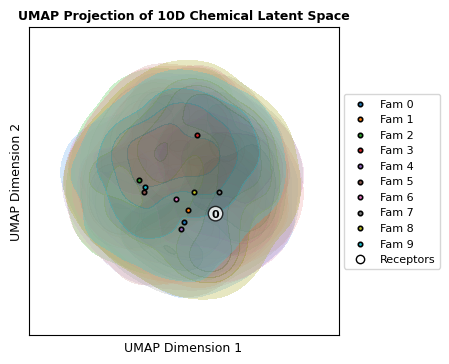

In [4]:
env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
# Plot the latent space visualization for each experiment
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])

In [ ]:
prev_env = None
train_out = list()
fig,ax = plt.subplots(ncols=3,figsize=(12,4))

for n_units in n_units_list: # e.g., [1, 2, 3, 4, 5, ...]
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    # Pass prev_env to start from the n-1 endpoint
    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False, prev_env=prev_env)
    
    train_out.append(train(CONF, env, rec, loss_fn, optimize, measurement_fns=[full_array_entropy, mean_receptor_distance,mutual_information_family,mutual_information_concentration]))
    
    # Save the current environment to be the foundation for the next iteration
    prev_env = env
    
    ax[0].plot(train_out[-1]['full_array_entropy'])
    ax[1].plot(train_out[-1]['mutual_information_family'])
    ax[2].plot(train_out[-1]['mutual_information_concentration'])



--- Starting training for n_units = 1 ---
Training for 500 epochs...
0.1


/app/run/notebooks/../../src/analysis_helper.py:427: RuntimeWarning: Mean of empty slice.
  return float(upper_triangle.mean())
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)



--- Starting training for n_units = 2 ---
Training for 500 epochs...
0.1

--- Starting training for n_units = 3 ---
Training for 500 epochs...
0.1

--- Starting training for n_units = 4 ---
Training for 500 epochs...
0.1

--- Starting training for n_units = 5 ---
Training for 500 epochs...
0.1

--- Starting training for n_units = 6 ---
Training for 500 epochs...
0.1

--- Starting training for n_units = 7 ---
Training for 500 epochs...
0.1



--- Starting training for n_units = 1 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 2 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 3 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 4 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 5 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 6 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 7 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 8 ---
Training for 500 epochs...
0.01

--- Starting training for n_units = 9 ---
Training for 500 epochs...
0.01


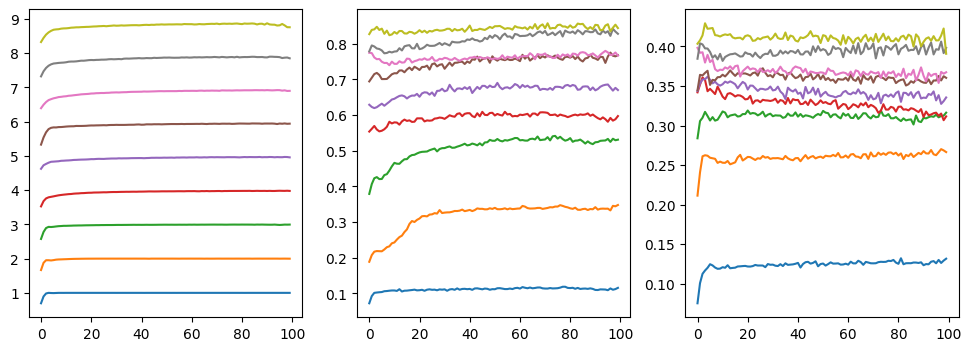

In [23]:
prev_env = None
train_out = list()
fig,ax = plt.subplots(ncols=3,figsize=(12,4))

for n_units in n_units_list: # e.g., [1, 2, 3, 4, 5, ...]
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    # Pass prev_env to start from the n-1 endpoint
    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False, prev_env=prev_env)
    
    train_out.append(train(CONF, env, rec, loss_fn, optimize, measurement_fns=[full_array_entropy, mean_receptor_distance,mutual_information_family,mutual_information_concentration]))
    
    # Save the current environment to be the foundation for the next iteration
    prev_env = env
    
    ax[0].plot(train_out[-1]['full_array_entropy'])
    ax[1].plot(train_out[-1]['mutual_information_family'])
    ax[2].plot(train_out[-1]['mutual_information_concentration'])


In [5]:
for n_units in n_units_list:
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
    
    print(env.base_energy_u)

    train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance,])


--- Starting training for n_units = 10 ---
Parameter containing:
tensor([-1431.5188, -1431.5188, -1431.5188, -1431.5188, -1431.5188, -1431.5188,
        -1431.5188, -1431.5188, -1431.5188, -1431.5188], device='cuda:0',
       requires_grad=True)
Training for 50000 epochs...
0.01
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_294935/4145326198.py", line 11, in <module>
    train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance,])
  File "/app/run/notebooks/../../run/run.py", line 157, in train
  File "/usr/local/lib/python3.10/dist-packages/torch/_tensor.py", line 503, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.10/dist-packages/torch/autograd/__init__.py", line 254, in backward
    Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 2144, in showtraceback
    s

(0.0, 10.0)

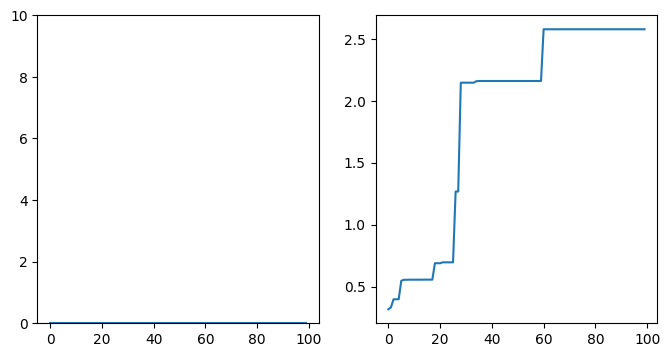

In [ ]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])
#ax[0].set_ylim(0,10)

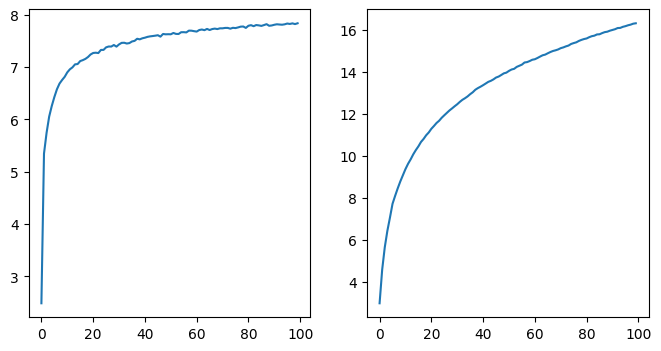

In [49]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])

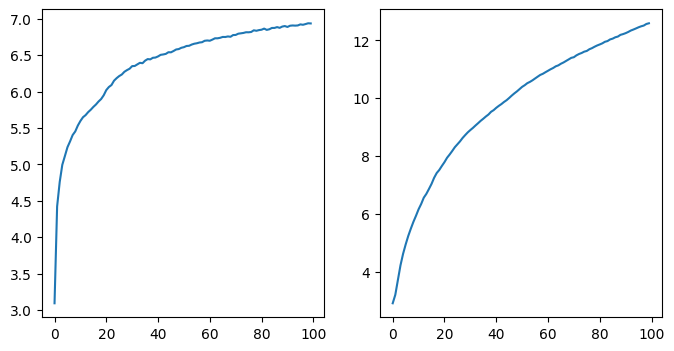

In [36]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])

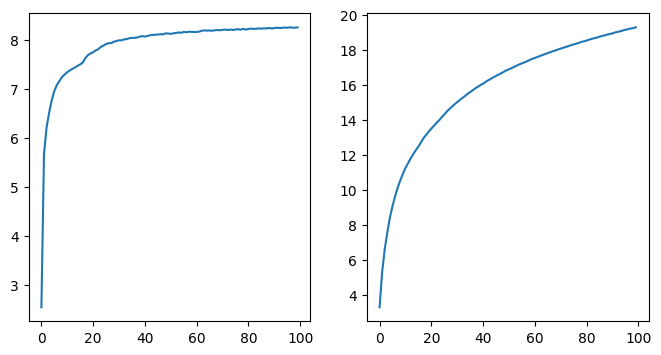

In [30]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[1].plot(train_out['mean_receptor_distance'])

Fitting UMAP... (This may take a few seconds)


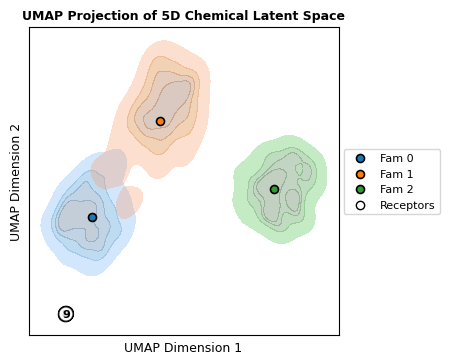

In [47]:
# Plot the latent space visualization for each experiment
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])

(<Figure size 400x300 with 3 Axes>,
 (<Axes: title={'center': 'Global Receptor Array Binary Response'}, ylabel='Activity Probability $p(a=1)$'>,
  <Axes: xlabel='Concentration (M)', ylabel='p(c)'>,
  <Axes: xlabel='Global Mass'>))

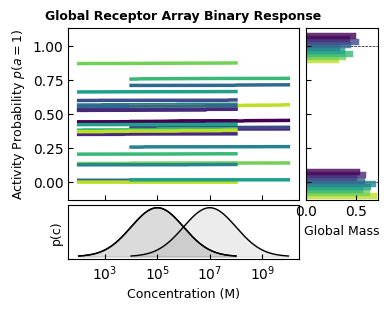

In [6]:
plot_summary(env,rec,CONF['receptor_indices'],loss_fn=loss_fn)